<a href="https://colab.research.google.com/github/scarlo27/Ciencia-de-datos-I/blob/main/proyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importar datasets

# from google.colab import files
# uploaded = files.upload()

 **Hipotesis 1:** “Los estudiantes con mayor número de interacciones en el entorno virtual (clics) tienen una mayor probabilidad de aprobar el curso.”

Variables:

X (input): Suma de clics (studentVle.num_clicks agrupado por estudiante)

Y (output): final_result → Binario (Pass o Fail)

**Hipotesis 2:** “El nivel educativo más alto (highest_education) y el número de intentos previos (num_of_prev_attempts) influyen en el rendimiento académico final.”

Variables:

X (input): highest_education, num_of_prev_attempts, studied_credits, age_band, etc.

Y (output): final_result (multiclase: Fail, Pass, Distinction, Withdrawn)

**Selección de Algoritmos (Planeación)**

Para Hipótesis 1 (Dicotómica):
→ Logistic Regression, Random Forest, SVM.

Para Hipótesis 2 (Multiclase o Ordinal):
→ Decision Trees, Random Forest, XGBoost o LightGBM.

Opcional:

Aplicar No Supervisado: K-Means para clusters de comportamiento.

Saving assessments.csv to assessments.csv
Saving courses.csv to courses.csv
Saving studentAssessment.csv to studentAssessment.csv
Saving studentInfo.csv to studentInfo.csv
Saving studentRegistration.csv to studentRegistration.csv
Saving studentVle.csv to studentVle.csv
Saving vle.csv to vle.csv
Saving AnonymisezData_oulad_context-Kongo-2024.csv to AnonymisezData_oulad_context-Kongo-2024.csv


/tmp/ipython-input-1-1435485214.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['total_clicks'].fillna(0, inplace=True)
/tmp/ipython-input-1-1435485214.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',


Logistic Regression - Best Threshold: 0.394
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      3442
           1       0.81      0.94      0.87      3077

    accuracy                           0.87      6519
   macro avg       0.87      0.87      0.87      6519
weighted avg       0.88      0.87      0.87      6519



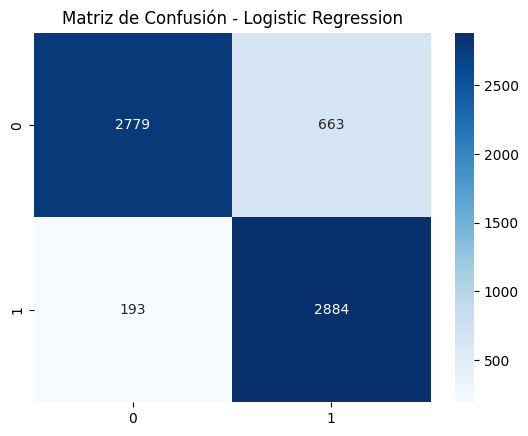


Random Forest - Best Threshold: 0.273
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      3442
           1       0.81      0.97      0.88      3077

    accuracy                           0.88      6519
   macro avg       0.89      0.88      0.88      6519
weighted avg       0.89      0.88      0.88      6519



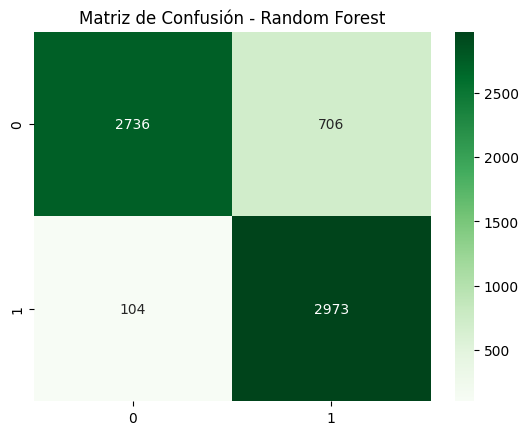


SVM - Classification Report
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      3442
           1       0.79      0.94      0.86      3077

    accuracy                           0.85      6519
   macro avg       0.86      0.86      0.85      6519
weighted avg       0.86      0.85      0.85      6519



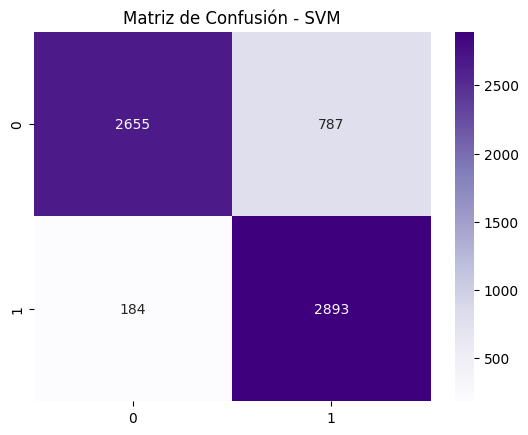

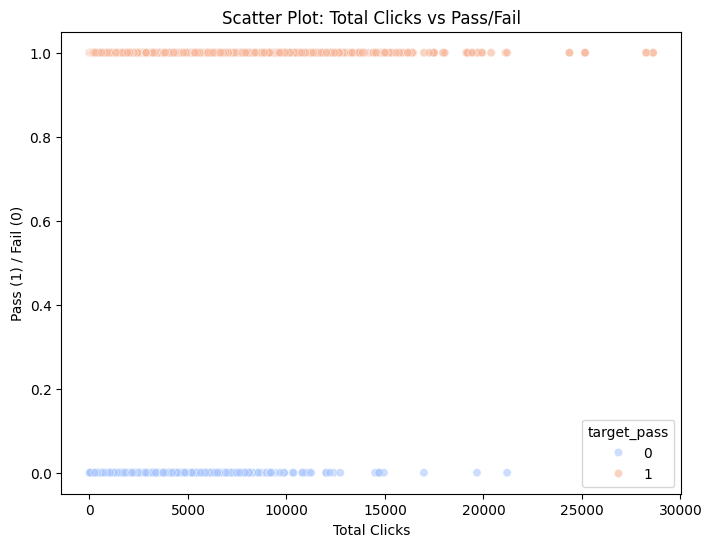


Decision Tree - Classification Report
              precision    recall  f1-score   support

 Distinction       0.22      0.77      0.34       605
        Fail       0.47      0.39      0.43      1411
        Pass       0.67      0.39      0.50      2472
   Withdrawn       0.73      0.63      0.68      2031

    accuracy                           0.50      6519
   macro avg       0.52      0.55      0.48      6519
weighted avg       0.60      0.50      0.52      6519



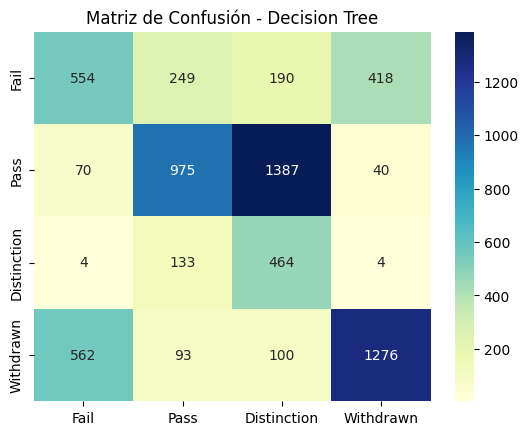


Random Forest Multiclass - Classification Report
              precision    recall  f1-score   support

 Distinction       0.27      0.59      0.37       605
        Fail       0.48      0.40      0.44      1411
        Pass       0.68      0.62      0.65      2472
   Withdrawn       0.74      0.65      0.69      2031

    accuracy                           0.58      6519
   macro avg       0.55      0.57      0.54      6519
weighted avg       0.62      0.58      0.59      6519



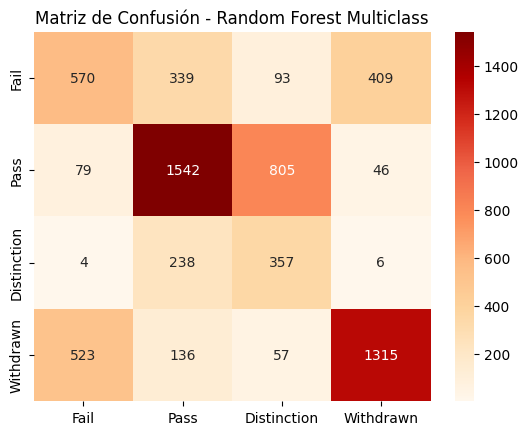

/tmp/ipython-input-1-1435485214.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


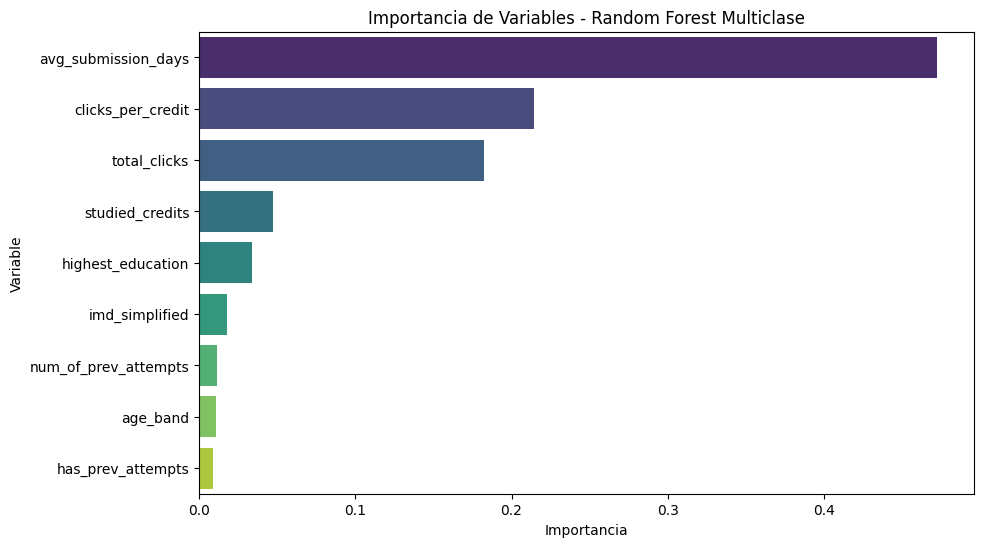

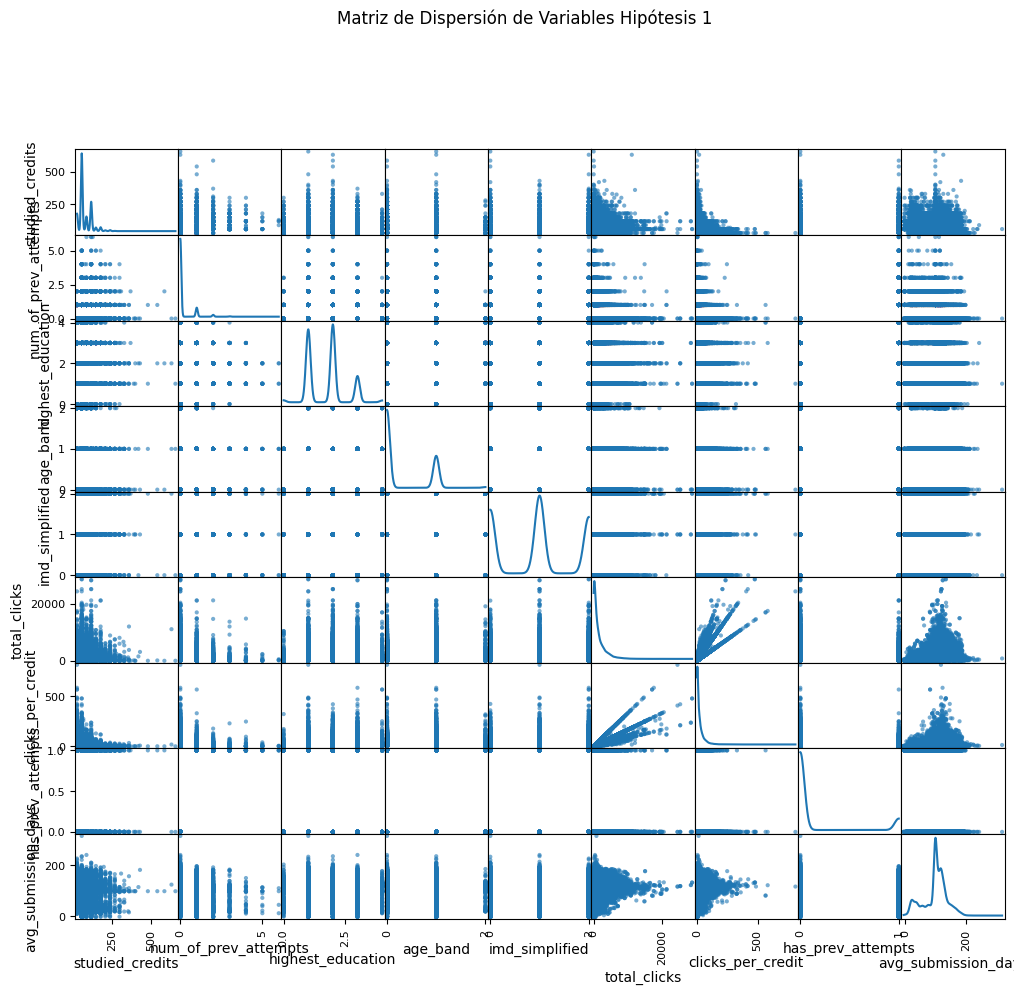

In [1]:
#  Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, precision_recall_curve
)
from pandas.plotting import scatter_matrix

# --- Cargar datasets ---
df_info = pd.read_csv('studentInfo.csv')
df_vle = pd.read_csv('studentVle.csv')
df_assess = pd.read_csv('studentAssessment.csv')

# --- Crear variables ---
# Total clicks por estudiante
df_clicks = df_vle.groupby('id_student')['sum_click'].sum().reset_index().rename(columns={'sum_click': 'total_clicks'})

# Promedio días de entrega por estudiante
df_avg_days = df_assess.groupby('id_student')['date_submitted'].mean().reset_index().rename(columns={'date_submitted': 'avg_submission_days'})

# Merge datasets
df_merged = df_info.merge(df_clicks, on='id_student', how='left')
df_merged = df_merged.merge(df_avg_days, on='id_student', how='left')

# Fill missing values
df_merged['total_clicks'].fillna(0, inplace=True)
df_merged['avg_submission_days'].fillna(df_merged['avg_submission_days'].mean(), inplace=True)

# Variable objetivo binaria (Hipótesis 1)
df_merged['target_pass'] = df_merged['final_result'].apply(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# --- Feature engineering ---
df_merged['clicks_per_credit'] = df_merged['total_clicks'] / df_merged['studied_credits'].replace(0, 1)
df_merged['clicks_per_credit'] = df_merged['clicks_per_credit'].replace([np.inf, -np.inf], 0).fillna(0)
df_merged['has_prev_attempts'] = df_merged['num_of_prev_attempts'].apply(lambda x: 1 if x > 0 else 0)

# IMD simplificado
def simplify_imd(imd):
    if imd in ['0-10%', '10-20', '20-30%']:
        return 0
    elif imd in ['30-40%', '40-50%', '50-60%', '60-70%']:
        return 1
    else:
        return 2
df_merged['imd_simplified'] = df_merged['imd_band'].map(simplify_imd)

# Codificar highest_education
edu_mapping = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df_merged['highest_education'] = df_merged['highest_education'].map(edu_mapping)

# Codificar age_band
age_mapping = {'0-35': 0, '35-55': 1, '55<=': 2}
df_merged['age_band'] = df_merged['age_band'].map(age_mapping)

# --- Variables para Hipótesis 1 (Binaria) ---
vars_h1 = [
    'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band',
    'imd_simplified', 'total_clicks', 'clicks_per_credit', 'has_prev_attempts', 'avg_submission_days'
]
X_h1 = df_merged[vars_h1].fillna(0)
y_h1 = df_merged['target_pass']

# Split Hipótesis 1
X_train_h1, X_test_h1, y_train_h1, y_test_h1 = train_test_split(
    X_h1, y_h1, test_size=0.2, random_state=42, stratify=y_h1
)

# --- Variables para Hipótesis 2 (Multiclase) ---
vars_h2 = vars_h1.copy()  # Mismas variables para simplificar
X_h2 = df_merged[vars_h2].fillna(0)
y_h2 = df_merged['final_result']

# Split Hipótesis 2
X_train_h2, X_test_h2, y_train_h2, y_test_h2 = train_test_split(
    X_h2, y_h2, test_size=0.2, random_state=42, stratify=y_h2
)

# --- Función para ajustar umbral y predecir ---
def predict_with_best_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:,1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2*precision*recall/(precision+recall+1e-6)
    best_idx = f1_scores.argmax()
    best_threshold = thresholds[best_idx]
    y_pred = (y_proba >= best_threshold).astype(int)
    return y_pred, best_threshold

# --- Entrenar y evaluar modelos Hipótesis 1 ---

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
log_model.fit(X_train_h1, y_train_h1)
y_pred_log, thr_log = predict_with_best_threshold(log_model, X_test_h1, y_test_h1)
print(f"\nLogistic Regression - Best Threshold: {thr_log:.3f}")
print(classification_report(y_test_h1, y_pred_log))
sns.heatmap(confusion_matrix(y_test_h1, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Logistic Regression')
plt.show()
pd.DataFrame({'y_test': y_test_h1.values, 'y_pred': y_pred_log}).to_csv('results_h1_logistic.csv', index=False)

# Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train_h1, y_train_h1)
y_pred_rf, thr_rf = predict_with_best_threshold(rf_model, X_test_h1, y_test_h1)
print(f"\nRandom Forest - Best Threshold: {thr_rf:.3f}")
print(classification_report(y_test_h1, y_pred_rf))
sns.heatmap(confusion_matrix(y_test_h1, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.show()
pd.DataFrame({'y_test': y_test_h1.values, 'y_pred': y_pred_rf}).to_csv('results_h1_rf.csv', index=False)

# SVM (sin ajuste de probabilidad, se usa predict directamente)
svm_model = SVC(class_weight='balanced', probability=True)
svm_model.fit(X_train_h1, y_train_h1)
y_pred_svm = svm_model.predict(X_test_h1)
print("\nSVM - Classification Report")
print(classification_report(y_test_h1, y_pred_svm))
sns.heatmap(confusion_matrix(y_test_h1, y_pred_svm), annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusión - SVM')
plt.show()
pd.DataFrame({'y_test': y_test_h1.values, 'y_pred': y_pred_svm}).to_csv('results_h1_svm.csv', index=False)

# --- Scatter plot para Hipótesis 1 ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='total_clicks', y='target_pass', data=df_merged, hue='target_pass', palette='coolwarm', alpha=0.6)
plt.title('Scatter Plot: Total Clicks vs Pass/Fail')
plt.xlabel('Total Clicks')
plt.ylabel('Pass (1) / Fail (0)')
plt.show()

# --- Entrenar y evaluar modelos Hipótesis 2 ---

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=7, class_weight='balanced')
dt_model.fit(X_train_h2, y_train_h2)
y_pred_dt = dt_model.predict(X_test_h2)
print("\nDecision Tree - Classification Report")
print(classification_report(y_test_h2, y_pred_dt))
sns.heatmap(confusion_matrix(y_test_h2, y_pred_dt, labels=['Fail', 'Pass', 'Distinction', 'Withdrawn']),
            annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Fail', 'Pass', 'Distinction', 'Withdrawn'],
            yticklabels=['Fail', 'Pass', 'Distinction', 'Withdrawn'])
plt.title('Matriz de Confusión - Decision Tree')
plt.show()
pd.DataFrame({'y_test': y_test_h2.values, 'y_pred': y_pred_dt}).to_csv('results_h2_dt.csv', index=False)

# Random Forest Multiclase
rf_model2 = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight='balanced')
rf_model2.fit(X_train_h2, y_train_h2)
y_pred_rf2 = rf_model2.predict(X_test_h2)
print("\nRandom Forest Multiclass - Classification Report")
print(classification_report(y_test_h2, y_pred_rf2))
sns.heatmap(confusion_matrix(y_test_h2, y_pred_rf2, labels=['Fail', 'Pass', 'Distinction', 'Withdrawn']),
            annot=True, fmt='d', cmap='OrRd',
            xticklabels=['Fail', 'Pass', 'Distinction', 'Withdrawn'],
            yticklabels=['Fail', 'Pass', 'Distinction', 'Withdrawn'])
plt.title('Matriz de Confusión - Random Forest Multiclass')
plt.show()
pd.DataFrame({'y_test': y_test_h2.values, 'y_pred': y_pred_rf2}).to_csv('results_h2_rf.csv', index=False)

# --- Importancia de variables para Random Forest multiclase ---
feat_imp = pd.Series(rf_model2.feature_importances_, index=vars_h2).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Importancia de Variables - Random Forest Multiclase')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

# --- Matriz de dispersión ---
scatter_matrix(df_merged[vars_h1], figsize=(12,10), diagonal='kde', alpha=0.6)
plt.suptitle('Matriz de Dispersión de Variables Hipótesis 1', y=1.02)
plt.show()


Vamos a generar un dataset sintetico para probar el modelo

final_result
Pass           0.736
Distinction    0.182
Fail           0.075
Withdrawn      0.007
Name: proportion, dtype: float64
✅ Dataset sintético guardado como 'synthetic_oulad_data.csv'


/tmp/ipython-input-11-1645558786.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='final_result', data=df_synthetic, palette='coolwarm')


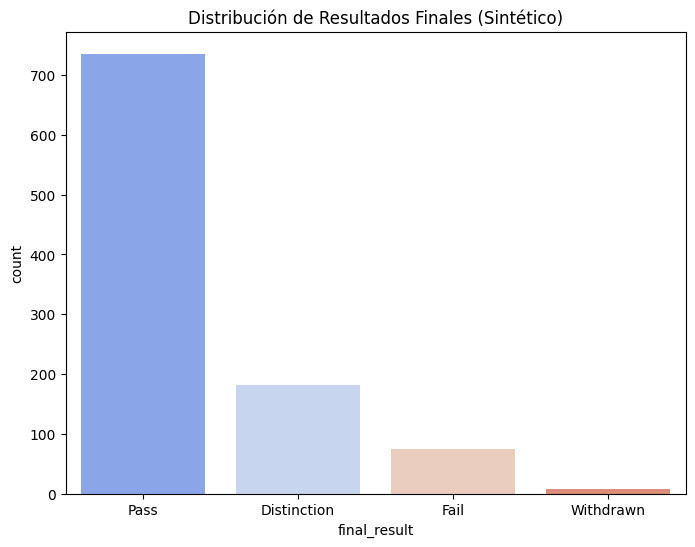

In [11]:
import pandas as pd
import numpy as np
import random

# --- Parámetros ---
n_samples = 1000  # Número de registros

# --- Generar variables sintéticas ---

np.random.seed(42)

gender = np.random.choice(['M', 'F'], size=n_samples)
region = np.random.choice(['North', 'South', 'East', 'West'], size=n_samples)
highest_education = np.random.choice([
    'No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
    'HE Qualification', 'Post Graduate Qualification'
], size=n_samples, p=[0.1, 0.2, 0.3, 0.3, 0.1])

imd_band = np.random.choice([
    '0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%',
    '60-70%', '70-80%', '80-90%', '90-100%'
], size=n_samples)

age_band = np.random.choice(['0-35', '35-55', '55<='], size=n_samples, p=[0.6, 0.3, 0.1])

num_of_prev_attempts = np.random.poisson(1, size=n_samples)
studied_credits = np.random.choice([30, 60, 90, 120], size=n_samples, p=[0.1, 0.5, 0.2, 0.2])
disability = np.random.choice(['Y', 'N'], size=n_samples, p=[0.1, 0.9])

total_clicks = np.random.normal(loc=500, scale=200, size=n_samples).clip(0)  # promedio 500 clicks
clicks_per_credit = total_clicks / studied_credits
avg_submission_days = np.random.normal(loc=70, scale=15, size=n_samples).clip(0, 150)

# --- Generar la variable objetivo final_result con reglas realistas ---

def assign_final_result(credits, attempts, clicks, avg_days):
    """
    Reglas heurísticas para determinar resultado final:
    - Buen desempeño: alto número de clics + pocas reintentos + entrega promedio temprana + créditos altos -> Pasa o Distinction
    - Mal desempeño: bajos clics + muchos intentos + entrega tarde -> Falla o Retira
    """
    score = 0

    if credits >= 60:
        score += 1
    if clicks > 400:
        score += 1
    if attempts == 0:
        score += 1
    if avg_days < 80:
        score += 1

    if score >= 3:
        return random.choices(['Pass', 'Distinction'], weights=[0.7, 0.3])[0]
    elif score == 2:
        return 'Pass'
    elif score == 1:
        return 'Fail'
    else:
        return random.choice(['Fail', 'Withdrawn'])

final_result = [
    assign_final_result(studied_credits[i], num_of_prev_attempts[i], total_clicks[i], avg_submission_days[i])
    for i in range(n_samples)
]

# --- Crear DataFrame ---
df_synthetic = pd.DataFrame({
    'gender': gender,
    'region': region,
    'highest_education': highest_education,
    'imd_band': imd_band,
    'age_band': age_band,
    'num_of_prev_attempts': num_of_prev_attempts,
    'studied_credits': studied_credits,
    'disability': disability,
    'total_clicks': total_clicks.round(0).astype(int),
    'clicks_per_credit': clicks_per_credit.round(2),
    'avg_submission_days': avg_submission_days.round(0).astype(int),
    'final_result': final_result
})

# Ver distribución
print(df_synthetic['final_result'].value_counts(normalize=True))

# Guardar para usar
df_synthetic.to_csv('synthetic_oulad_data.csv', index=False)
print("Dataset sintético guardado como 'synthetic_oulad_data.csv'")

# Visualización rápida
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(x='final_result', data=df_synthetic, palette='coolwarm')
plt.title('Distribución de Resultados Finales (Sintético)')
plt.show()


Cargar el dataset sintético y preparar las variables

In [12]:
#  Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#  Cargar el dataset sintético
df_synth = pd.read_csv('synthetic_oulad_data.csv')

#  Codificar variables categóricas igual que en el modelo original

edu_mapping = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df_synth['highest_education'] = df_synth['highest_education'].map(edu_mapping)

age_mapping = {'0-35': 0, '35-55': 1, '55<=': 2}
df_synth['age_band'] = df_synth['age_band'].map(age_mapping)

def simplify_imd(imd):
    if imd in ['0-10%', '10-20', '20-30%']:
        return 0
    elif imd in ['30-40%', '40-50%', '50-60%', '60-70%']:
        return 1
    else:
        return 2

df_synth['imd_simplified'] = df_synth['imd_band'].map(simplify_imd)

# Variables predictoras y target (Binaria)
df_synth['target_pass'] = df_synth['final_result'].apply(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

vars_predictoras = [
    'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band',
    'imd_simplified', 'total_clicks', 'clicks_per_credit', 'avg_submission_days'
]

X_synth = df_synth[vars_predictoras].fillna(0)
y_synth = df_synth['target_pass']

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_synth, y_synth, test_size=0.2, random_state=42, stratify=y_synth)


Probando los modelos con el dataset sintético


📊 Logistic Regression:
              precision    recall  f1-score   support

           0       0.39      0.81      0.53        16
           1       0.98      0.89      0.93       184

    accuracy                           0.89       200
   macro avg       0.69      0.85      0.73       200
weighted avg       0.93      0.89      0.90       200



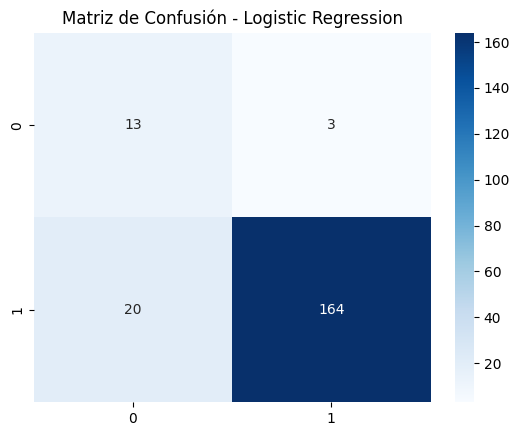


📊 Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.99      1.00      1.00       184

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



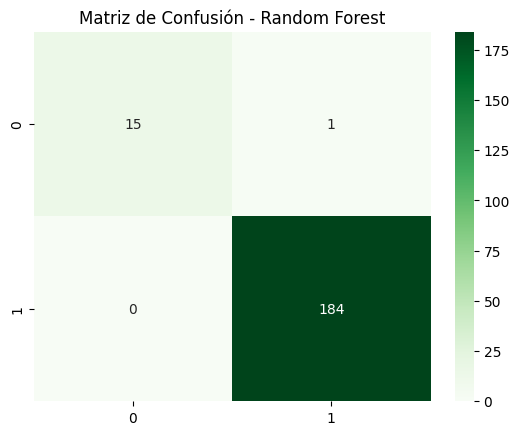

In [13]:
#  Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n Logistic Regression:")
print(classification_report(y_test, y_pred_log))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Logistic Regression')
plt.show()

# 🚀 Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n Random Forest:")
print(classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

#  Guardar predicciones
pd.DataFrame({'y_test': y_test.values, 'y_pred_log': y_pred_log, 'y_pred_rf': y_pred_rf}).to_csv('synthetic_predictions.csv', index=False)
